In [22]:
# Common setup: true function and common data for all experiments

import numpy as np
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge


GLOBAL_SEED = 2026
GAMMA = 0.3

# Common distribution settings (project-aligned)
B = 5.0
LOW, MID, HIGH = 0.0, 0.5, 1.0
# Compatibility aliases to keep attachment downstream cells unchanged
P_LOW, P_HIGH = LOW, HIGH
Q_LOW, Q_HIGH = LOW, HIGH


# Common dataset settings for visualization
N_BASE_DATA = 100
NOISE_STD_BASE = 1.0


def true_function(x):
    """Ground-truth regression function used by all experiments."""
    x = np.asarray(x)
    return np.cos(2 * np.pi * x) - 1


def sample_from_p(n_samples, rng):
    """Sample from source: B/(B+1) U[0,1/2] + 1/(B+1) U[1/2,1]."""
    n_left = int(n_samples * B / (B + 1))
    x_left = rng.random(n_left) / 2
    x_right = 0.5 + rng.random(n_samples - n_left) / 2
    x = np.concatenate([x_left, x_right])
    rng.shuffle(x)
    return x


def sample_from_q(n_samples, rng):
    """Sample from target: 1/(B+1) U[0,1/2] + B/(B+1) U[1/2,1]."""
    n_right = int(n_samples * B / (B + 1))
    x_left = rng.random(n_samples - n_right) / 2
    x_right = 0.5 + rng.random(n_right) / 2
    x = np.concatenate([x_left, x_right])
    rng.shuffle(x)
    return x


def p_density(x):
    x = np.asarray(x)
    left = 2 * B / (B + 1)
    right = 2 / (B + 1)
    return np.where((x >= 0) & (x <= 0.5), left, np.where((x > 0.5) & (x <= 1.0), right, 0.0))


def q_density(x):
    x = np.asarray(x)
    left = 2 / (B + 1)
    right = 2 * B / (B + 1)
    return np.where((x >= 0) & (x <= 0.5), left, np.where((x > 0.5) & (x <= 1.0), right, 0.0))


def rbf_kernel(x, z, gamma):
    x = np.asarray(x).reshape(-1, 1)
    z = np.asarray(z).reshape(-1, 1)
    return np.exp(-gamma * (x - z.T) ** 2)


class WeightedKernelRidge:
    def __init__(self, gamma=0.3, lam=0.05):
        self.gamma = gamma
        self.lam = lam
        self.x_train = None
        self.dual_coef_ = None

    def fit(self, x, y, sample_weight):
        x = np.asarray(x).ravel()
        y = np.asarray(y).ravel()
        w = np.asarray(sample_weight).ravel()

        kernel_mat = rbf_kernel(x, x, self.gamma)
        weight_mat = np.diag(w)
        system_mat = weight_mat @ kernel_mat + self.lam * np.eye(len(x))
        rhs = weight_mat @ y

        self.dual_coef_ = np.linalg.solve(system_mat, rhs)
        self.x_train = x
        return self

    def predict(self, x_test):
        kernel_test = rbf_kernel(x_test, self.x_train, self.gamma)
        return kernel_test @ self.dual_coef_


rng_data = np.random.default_rng(GLOBAL_SEED)
X_P_DATA = sample_from_p(N_BASE_DATA, rng_data)
X_Q_DATA = sample_from_q(N_BASE_DATA, rng_data)
y_P_DATA = true_function(X_P_DATA) + rng_data.normal(0.0, NOISE_STD_BASE, size=N_BASE_DATA)
y_Q_DATA = true_function(X_Q_DATA) + rng_data.normal(0.0, NOISE_STD_BASE, size=N_BASE_DATA)

# Common Monte Carlo training datasets used by Experiments 2 and 3
N_TRAIN_MONTE = 400
N_REP_MONTE = 500
train_data = []
for rep in range(N_REP_MONTE):
    rng_rep = np.random.default_rng(rep)
    x_train = sample_from_p(N_TRAIN_MONTE, rng_rep)
    y_train = true_function(x_train) + rng_rep.normal(0.0, NOISE_STD_BASE, size=N_TRAIN_MONTE)
    train_data.append((x_train, y_train))

# Dedicated common evaluation datasets used by later cells
N_EVAL_COMMON = 2000
rng_eval = np.random.default_rng(GLOBAL_SEED + 1)
X_EVAL_P_DATA = sample_from_p(N_EVAL_COMMON, rng_eval)
X_EVAL_Q_DATA = sample_from_q(N_EVAL_COMMON, rng_eval)
y_EVAL_P_DATA = true_function(X_EVAL_P_DATA)
y_EVAL_Q_DATA = true_function(X_EVAL_Q_DATA)

print("Common setup ready: true_function + common datasets for all experiments")



Common setup ready: true_function + common datasets for all experiments


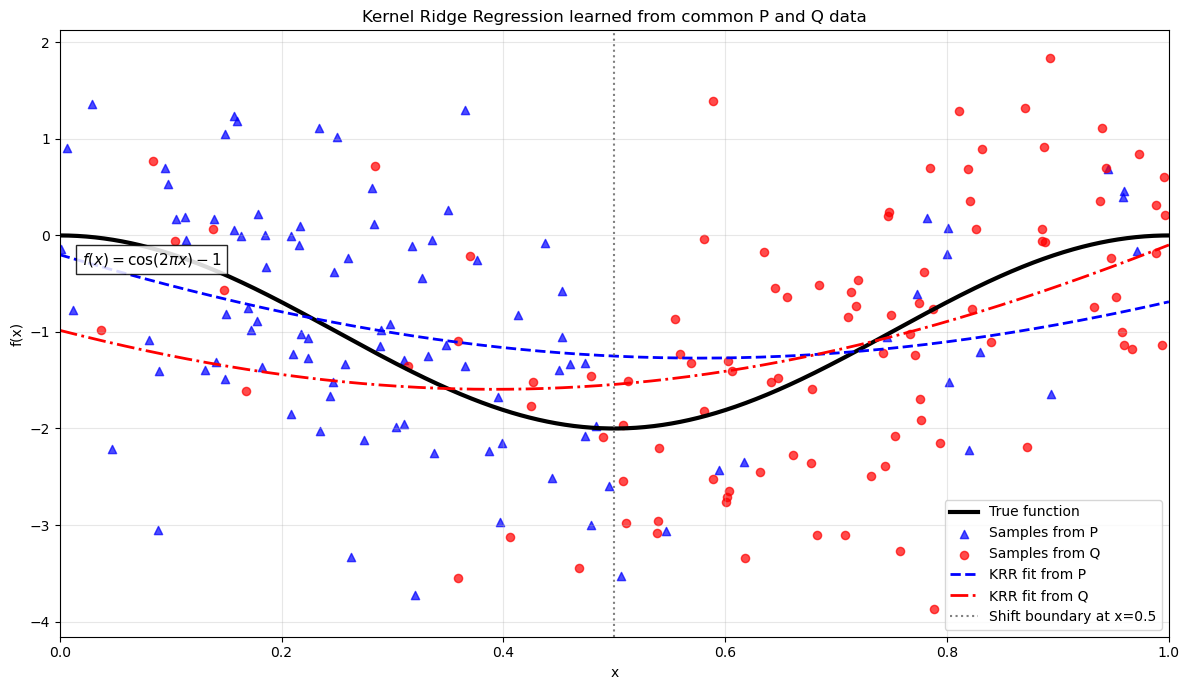

In [23]:
####### Simulation showing the impact of covariate shift

# Reuse common true_function and common datasets from the first cell.
X_P = X_P_DATA
y_P = y_P_DATA
X_Q = X_Q_DATA
y_Q = y_Q_DATA

krr_p = KernelRidge(kernel="rbf", alpha=0.1, gamma=0.3)
krr_q = KernelRidge(kernel="rbf", alpha=0.1, gamma=0.3)
krr_p.fit(X_P.reshape(-1, 1), y_P)
krr_q.fit(X_Q.reshape(-1, 1), y_Q)

x_grid = np.linspace(0, 1, 1000)
y_true = true_function(x_grid)
y_pred_p = krr_p.predict(x_grid.reshape(-1, 1))
y_pred_q = krr_q.predict(x_grid.reshape(-1, 1))

plt.figure(figsize=(12, 7))

formula_text = r"$f(x)=\cos(2\pi x)-1$"
plt.text(
    0.02,
    np.max(y_true) - 0.3,
    formula_text,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="black"),
)

plt.plot(x_grid, y_true, color="black", linewidth=3, label="True function")
plt.scatter(X_P, y_P, color="blue", alpha=0.7, s=35, marker="^", label="Samples from P")
plt.scatter(X_Q, y_Q, color="red", alpha=0.7, s=35, label="Samples from Q")
plt.plot(x_grid, y_pred_p, color="blue", linewidth=2.0, linestyle="--", label="KRR fit from P")
plt.plot(x_grid, y_pred_q, color="red", linewidth=2.0, linestyle="-.", label="KRR fit from Q")

plt.axvline(0.5, color="gray", linestyle=":", linewidth=1.5, label="Shift boundary at x=0.5")
plt.xlim([0, 1])
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Kernel Ridge Regression learned from common P and Q data")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



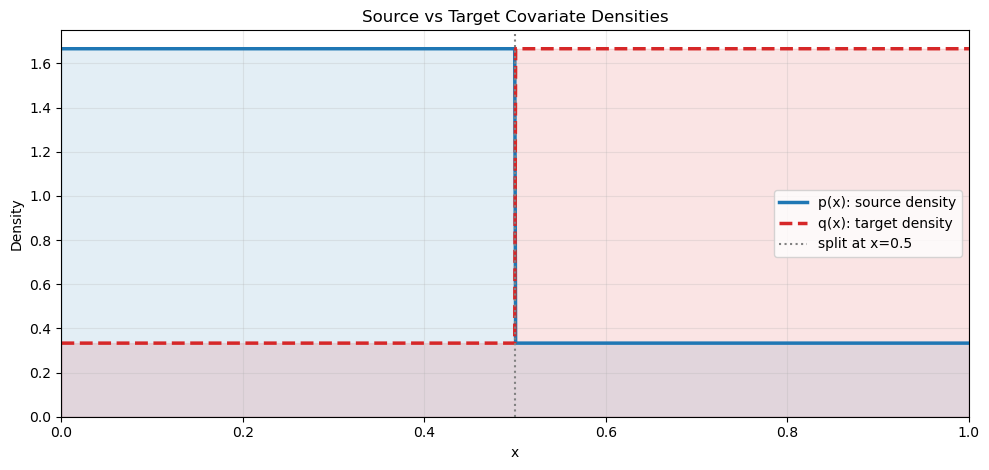

Left half [0,0.5]: p = 1.6666666666666667 , q = 0.3333333333333333
Right half (0.5,1]: p = 0.3333333333333333 , q = 1.6666666666666667


In [30]:
# Density comparison: p(x) vs q(x)
x_grid = np.linspace(P_LOW, P_HIGH, 1000)
p_vals = p_density(x_grid)
q_vals = q_density(x_grid)

plt.figure(figsize=(10, 4.8))
plt.plot(x_grid, p_vals, color='tab:blue', linewidth=2.5, label='p(x): source density')
plt.plot(x_grid, q_vals, color='tab:red', linewidth=2.5, linestyle='--', label='q(x): target density')
plt.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, label='split at x=0.5')
plt.fill_between(x_grid, 0, p_vals, color='tab:blue', alpha=0.12)
plt.fill_between(x_grid, 0, q_vals, color='tab:red', alpha=0.12)
plt.xlim(P_LOW, P_HIGH)
plt.ylim(bottom=0)
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Source vs Target Covariate Densities')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Left half [0,0.5]: p =', p_density(np.array([0.25]))[0], ', q =', q_density(np.array([0.25]))[0])
print('Right half (0.5,1]: p =', p_density(np.array([0.75]))[0], ', q =', q_density(np.array([0.75]))[0])


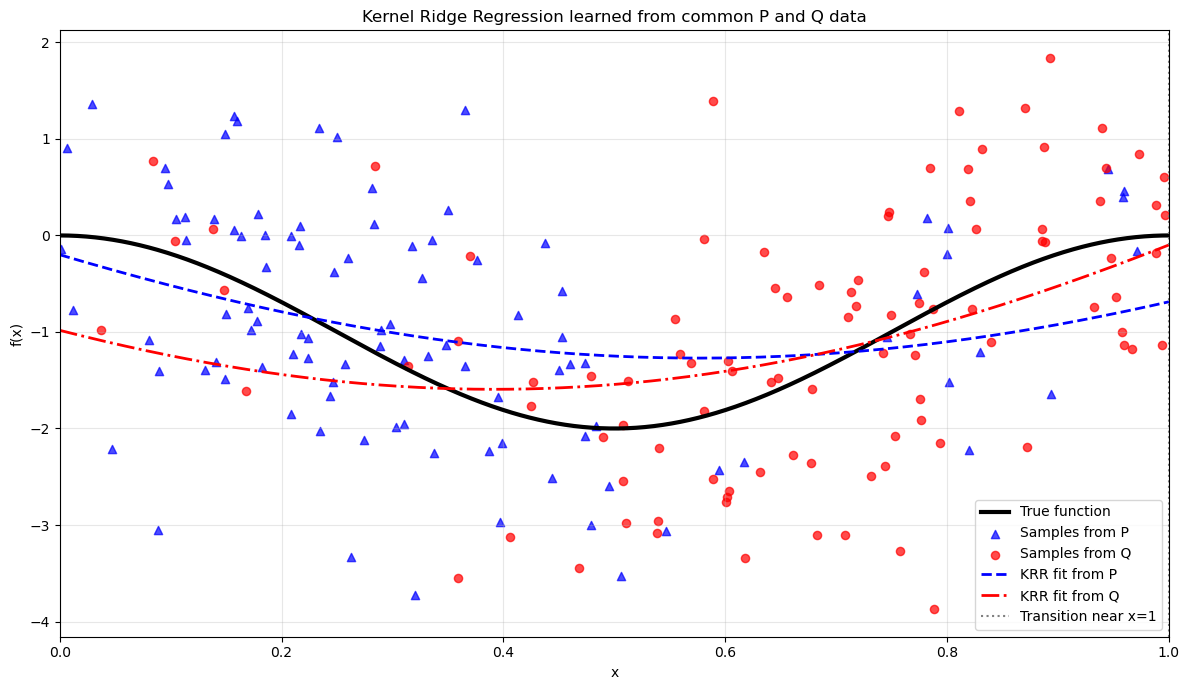

In [24]:
####### Simulation showing the impact of covariate shift

# Reuse common true_function and common datasets from the first cell.
X_P = X_P_DATA
y_P = y_P_DATA
X_Q = X_Q_DATA
y_Q = y_Q_DATA

# sklearn KRR uses alpha as regularization (keep alpha at the original scale).
ALPHA_KRR = 0.1
krr_p = KernelRidge(kernel="rbf", alpha=ALPHA_KRR, gamma=0.3)
krr_q = KernelRidge(kernel="rbf", alpha=ALPHA_KRR, gamma=0.3)
krr_p.fit(X_P.reshape(-1, 1), y_P)
krr_q.fit(X_Q.reshape(-1, 1), y_Q)

x_min_plot = min(P_LOW, Q_LOW)
x_max_plot = max(P_HIGH, Q_HIGH)
x_grid = np.linspace(x_min_plot, x_max_plot, 1000)
y_true = true_function(x_grid)
y_pred_p = krr_p.predict(x_grid.reshape(-1, 1))
y_pred_q = krr_q.predict(x_grid.reshape(-1, 1))

plt.figure(figsize=(12, 7))

plt.plot(x_grid, y_true, color="black", linewidth=3, label="True function")
plt.scatter(X_P, y_P, color="blue", alpha=0.7, s=35, marker="^", label="Samples from P")
plt.scatter(X_Q, y_Q, color="red", alpha=0.7, s=35, label="Samples from Q")
plt.plot(x_grid, y_pred_p, color="blue", linewidth=2.0, linestyle="--", label="KRR fit from P")
plt.plot(x_grid, y_pred_q, color="red", linewidth=2.0, linestyle="-.", label="KRR fit from Q")

plt.axvline(1, color="gray", linestyle=":", linewidth=1.5, label="Transition near x=1")
plt.xlim([x_min_plot, x_max_plot])
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Kernel Ridge Regression learned from common P and Q data")
plt.legend()
plt.grid(alpha=0.3)

from pathlib import Path
output_dir = Path("l2norm_imgs")
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(output_dir / "01_covariate_shift_fit.png", dpi=300, bbox_inches="tight")
plt.show()


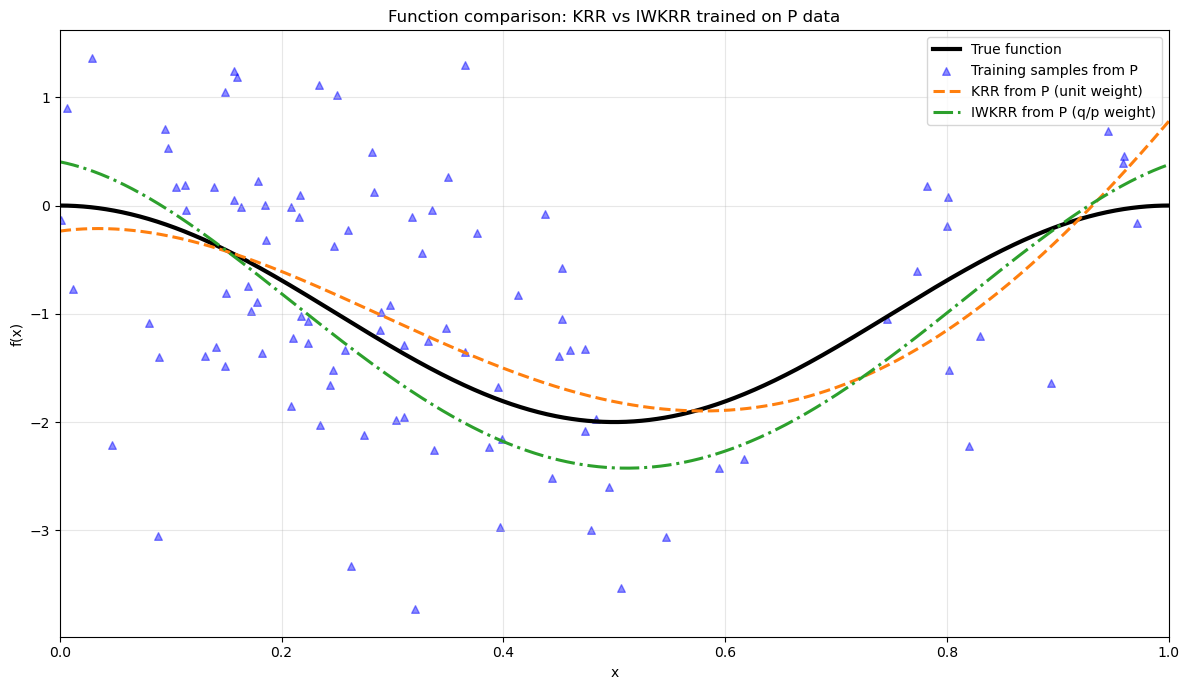

In [25]:
####### Compare KRR vs IWKRR learned from P data

# Train both models on the same P dataset.
X_train = X_P_DATA
y_train = y_P_DATA

LAM_KRR = 1e-05
LAM_IWKRR = 1e-05

# KRR is implemented as weighted KRR with unit weights.
w_krr = np.ones(len(X_train))

# Importance weights for IWKRR: q(x)/p(x).
ratio = q_density(X_train) / np.maximum(p_density(X_train), 1e-12)
w_iw = ratio

model_krr = WeightedKernelRidge(gamma=GAMMA, lam=LAM_KRR)
model_iw = WeightedKernelRidge(gamma=GAMMA, lam=LAM_IWKRR)
model_krr.fit(X_train, y_train, sample_weight=w_krr)
model_iw.fit(X_train, y_train, sample_weight=w_iw)

x_min_plot = min(P_LOW, Q_LOW)
x_max_plot = max(P_HIGH, Q_HIGH)
x_grid = np.linspace(x_min_plot, x_max_plot, 1000)
y_true = true_function(x_grid)
y_pred_krr = model_krr.predict(x_grid)
y_pred_iw = model_iw.predict(x_grid)

plt.figure(figsize=(12, 7))
plt.plot(x_grid, y_true, color="black", linewidth=3, label="True function")
plt.scatter(X_train, y_train, color="blue", alpha=0.45, s=30, marker="^", label="Training samples from P")
plt.plot(x_grid, y_pred_krr, color="tab:orange", linewidth=2.2, linestyle="--", label="KRR from P (unit weight)")
plt.plot(x_grid, y_pred_iw, color="tab:green", linewidth=2.2, linestyle="-.", label="IWKRR from P (q/p weight)")

plt.xlim([x_min_plot, x_max_plot])
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function comparison: KRR vs IWKRR trained on P data")
plt.legend()
plt.grid(alpha=0.3)

from pathlib import Path
output_dir = Path("l2norm_imgs")
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(output_dir / "01b_pdata_krr_vs_iwkrr_fit.png", dpi=300, bbox_inches="tight")
plt.show()


===== Lambda search for minimum mean L2(P) =====
lambda=1e-06 | L2(P) mean=0.1037, std=0.0327
lambda=3e-06 | L2(P) mean=0.1025, std=0.0327
lambda=1e-05 | L2(P) mean=0.1038, std=0.0331
lambda=3e-05 | L2(P) mean=0.1181, std=0.0316
lambda=0.0001 | L2(P) mean=0.1482, std=0.0240
lambda=0.0003 | L2(P) mean=0.1680, std=0.0191
lambda=0.001 | L2(P) mean=0.1774, std=0.0171
lambda=0.003 | L2(P) mean=0.1827, std=0.0163
lambda=0.01 | L2(P) mean=0.1908, std=0.0154

===== Selected lambda over 500 repetitions =====
best lambda = 3e-06 (minimizes mean L2(P))
L2(P) norm: mean=0.1025, std=0.0327, min=0.0253, max=0.2172
L2(Q) norm: mean=0.1506, std=0.0688, min=0.0251, max=0.3999


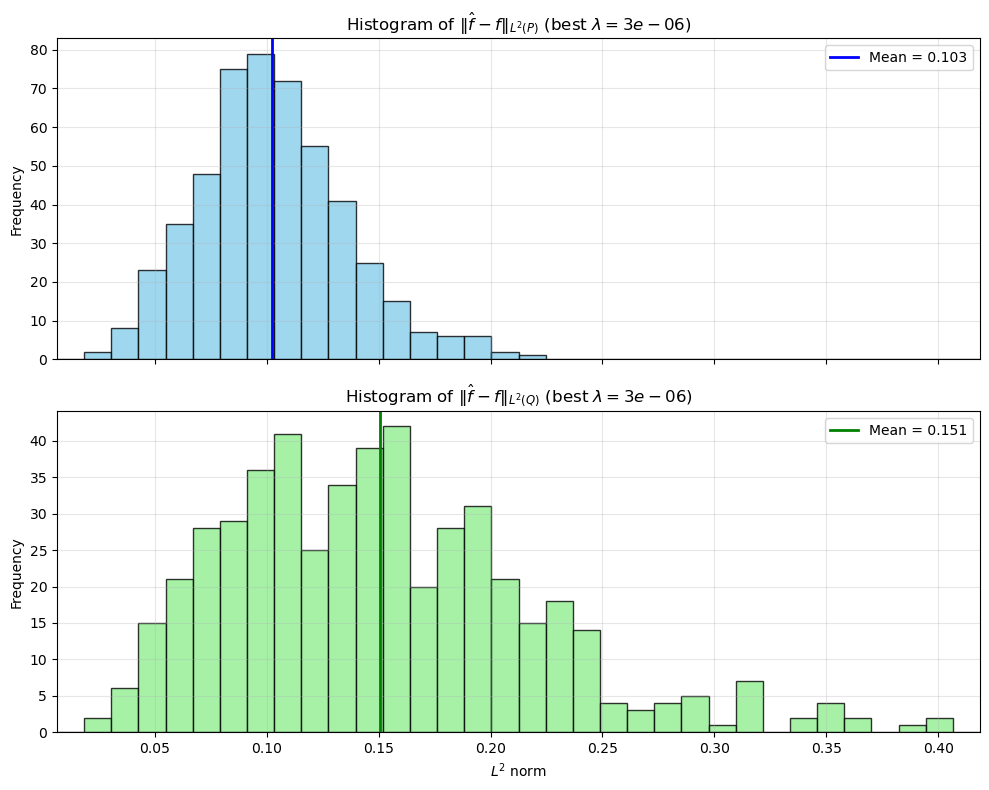

In [26]:
############################# Histogram of ||hat f - f||_{L2(P)} and ||hat f - f||_{L2(Q)} where hat f is learned from KRR under P distribution

# Reuse common true_function and common samplers from the first cell.
N_REP = N_REP_MONTE
LAMBDA_GRID = np.array([1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2])

# Use dedicated common evaluation sets from the first cell.
X_eval_p = X_EVAL_P_DATA
X_eval_q = X_EVAL_Q_DATA
f_eval_p = true_function(X_eval_p)
f_eval_q = true_function(X_eval_q)

best_lambda = None
best_l2p_mean = np.inf
best_errors_p = None
best_errors_q = None

print("===== Lambda search for minimum mean L2(P) =====")
for lam in LAMBDA_GRID:
    errors_p_lam = []
    errors_q_lam = []

    for rep in range(N_REP):
        x_train, y_train = train_data[rep]

        unit_weight = np.ones(len(x_train))
        model = WeightedKernelRidge(gamma=GAMMA, lam=lam)
        model.fit(x_train, y_train, sample_weight=unit_weight)

        pred_p = model.predict(X_eval_p)
        pred_q = model.predict(X_eval_q)

        errors_p_lam.append(np.sqrt(np.mean((pred_p - f_eval_p) ** 2)))
        errors_q_lam.append(np.sqrt(np.mean((pred_q - f_eval_q) ** 2)))

    errors_p_lam = np.array(errors_p_lam)
    errors_q_lam = np.array(errors_q_lam)
    mean_p_lam = errors_p_lam.mean()

    print(
        f"lambda={lam:.4g} | L2(P) mean={mean_p_lam:.4f}, std={errors_p_lam.std():.4f}"
    )

    if mean_p_lam < best_l2p_mean:
        best_l2p_mean = mean_p_lam
        best_lambda = lam
        best_errors_p = errors_p_lam
        best_errors_q = errors_q_lam

errors_p = best_errors_p
errors_q = best_errors_q

print(f"\n===== Selected lambda over {N_REP} repetitions =====")
print(f"best lambda = {best_lambda:.4g} (minimizes mean L2(P))")
print(
    f"L2(P) norm: mean={errors_p.mean():.4f}, std={errors_p.std():.4f}, "
    f"min={errors_p.min():.4f}, max={errors_p.max():.4f}"
)
print(
    f"L2(Q) norm: mean={errors_q.mean():.4f}, std={errors_q.std():.4f}, "
    f"min={errors_q.min():.4f}, max={errors_q.max():.4f}"
)

# Plot style aligned with other experiments: top/bottom histograms, shared x-axis.
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

x_min = min(errors_p.min(), errors_q.min())
x_max = max(errors_p.max(), errors_q.max())
pad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)
x_min -= pad
x_max += pad
bins = np.linspace(x_min, x_max, 35)

axes[0].hist(errors_p, bins=bins, color="skyblue", edgecolor="black", alpha=0.8)
axes[0].axvline(errors_p.mean(), color="blue", linestyle="-", linewidth=2, label=f"Mean = {errors_p.mean():.3f}")
axes[0].set_title(rf"Histogram of $\|\hat f-f\|_{{L^2(P)}}$ (best $\lambda={best_lambda:.4g}$)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(errors_q, bins=bins, color="lightgreen", edgecolor="black", alpha=0.8)
axes[1].axvline(errors_q.mean(), color="green", linestyle="-", linewidth=2, label=f"Mean = {errors_q.mean():.3f}")
axes[1].set_title(rf"Histogram of $\|\hat f-f\|_{{L^2(Q)}}$ (best $\lambda={best_lambda:.4g}$)")
axes[1].set_xlabel(r"$L^2$ norm")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(x_min, x_max)
axes[1].legend()
axes[1].grid(alpha=0.3)

from pathlib import Path
output_dir = Path("l2norm_imgs")
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(output_dir / "02_l2p_l2q_hist.png", dpi=300, bbox_inches="tight")
plt.show()


In [27]:
########## Importance weighting only: tune lambda

N_REP = N_REP_MONTE
LAMBDA_GRID_W1 = np.array([1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2])

# Dedicated common Q evaluation set.
X_eval_q = X_EVAL_Q_DATA
f_eval_q = true_function(X_eval_q)

best_lambda_w1 = None
best_errors_w1 = None
best_mean_w1 = np.inf

print("===== Importance weighting: lambda tuning =====")
for lam in LAMBDA_GRID_W1:
    errors_w1_lam = []

    for rep in range(N_REP):
        x_train, y_train = train_data[rep]
        ratio = q_density(x_train) / np.maximum(p_density(x_train), 1e-12)
        w1 = ratio

        model_w1 = WeightedKernelRidge(gamma=GAMMA, lam=lam)
        model_w1.fit(x_train, y_train, sample_weight=w1)
        pred_q_w1 = model_w1.predict(X_eval_q)
        errors_w1_lam.append(np.sqrt(np.mean((pred_q_w1 - f_eval_q) ** 2)))

    errors_w1_lam = np.array(errors_w1_lam)
    mean_w1_lam = errors_w1_lam.mean()

    print(f"lambda={lam:.4g} | L2(Q) mean={mean_w1_lam:.4f}, std={errors_w1_lam.std():.4f}")

    if mean_w1_lam < best_mean_w1:
        best_mean_w1 = mean_w1_lam
        best_lambda_w1 = lam
        best_errors_w1 = errors_w1_lam

errors_w1 = best_errors_w1
print(f"selected lambda_w1={best_lambda_w1:.4g}, mean={errors_w1.mean():.4f}")


===== Importance weighting: lambda tuning =====
lambda=1e-06 | L2(Q) mean=0.1806, std=0.0744
lambda=3e-06 | L2(Q) mean=0.1780, std=0.0739
lambda=1e-05 | L2(Q) mean=0.1755, std=0.0722
lambda=3e-05 | L2(Q) mean=0.1812, std=0.0677
lambda=0.0001 | L2(Q) mean=0.2015, std=0.0589
lambda=0.0003 | L2(Q) mean=0.2161, std=0.0534
lambda=0.001 | L2(Q) mean=0.2211, std=0.0504
lambda=0.003 | L2(Q) mean=0.2215, std=0.0484
lambda=0.01 | L2(Q) mean=0.2251, std=0.0462
selected lambda_w1=1e-05, mean=0.1755


In [28]:
########## Truncated importance weighting only: tune lambda and weight_cap

LAMBDA_GRID_W2 = np.array([1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2])
WEIGHT_CAP_GRID = np.array([2.0, 3.0, 5.0, 8.0, 10.0])

best_lambda_w2 = None
best_weight_cap = None
best_errors_w2 = None
best_mean_w2 = np.inf

print("===== Truncated weighting: lambda + weight_cap tuning =====")
for cap in WEIGHT_CAP_GRID:
    for lam in LAMBDA_GRID_W2:
        errors_w2_pair = []

        for rep in range(N_REP):
            x_train, y_train = train_data[rep]
            ratio = q_density(x_train) / np.maximum(p_density(x_train), 1e-12)
            w2 = np.minimum(ratio, cap)

            model_w2 = WeightedKernelRidge(gamma=GAMMA, lam=lam)
            model_w2.fit(x_train, y_train, sample_weight=w2)
            pred_q_w2 = model_w2.predict(X_eval_q)
            errors_w2_pair.append(np.sqrt(np.mean((pred_q_w2 - f_eval_q) ** 2)))

        errors_w2_pair = np.array(errors_w2_pair)
        mean_w2_pair = errors_w2_pair.mean()

        print(
            f"cap={cap:.2f}, lambda={lam:.4g} | "
            f"L2(Q) mean={mean_w2_pair:.4f}, std={errors_w2_pair.std():.4f}"
        )

        if mean_w2_pair < best_mean_w2:
            best_mean_w2 = mean_w2_pair
            best_lambda_w2 = lam
            best_weight_cap = cap
            best_errors_w2 = errors_w2_pair

errors_w2 = best_errors_w2
print(
    f"selected lambda_w2={best_lambda_w2:.4g}, "
    f"weight_cap={best_weight_cap:.2f}, mean={errors_w2.mean():.4f}"
)


===== Truncated weighting: lambda + weight_cap tuning =====
cap=2.00, lambda=1e-06 | L2(Q) mean=0.1688, std=0.0720
cap=2.00, lambda=3e-06 | L2(Q) mean=0.1657, std=0.0715
cap=2.00, lambda=1e-05 | L2(Q) mean=0.1656, std=0.0702
cap=2.00, lambda=3e-05 | L2(Q) mean=0.1806, std=0.0641
cap=2.00, lambda=0.0001 | L2(Q) mean=0.2047, std=0.0550
cap=2.00, lambda=0.0003 | L2(Q) mean=0.2171, std=0.0501
cap=2.00, lambda=0.001 | L2(Q) mean=0.2209, std=0.0460
cap=2.00, lambda=0.003 | L2(Q) mean=0.2215, std=0.0426
cap=2.00, lambda=0.01 | L2(Q) mean=0.2235, std=0.0407
cap=3.00, lambda=1e-06 | L2(Q) mean=0.1740, std=0.0732
cap=3.00, lambda=3e-06 | L2(Q) mean=0.1711, std=0.0725
cap=3.00, lambda=1e-05 | L2(Q) mean=0.1691, std=0.0711
cap=3.00, lambda=3e-05 | L2(Q) mean=0.1790, std=0.0662
cap=3.00, lambda=0.0001 | L2(Q) mean=0.2015, std=0.0571
cap=3.00, lambda=0.0003 | L2(Q) mean=0.2151, std=0.0519
cap=3.00, lambda=0.001 | L2(Q) mean=0.2199, std=0.0483
cap=3.00, lambda=0.003 | L2(Q) mean=0.2213, std=0.0454
ca

===== Summary over 500 repetitions =====
w1(x)=q(x)/p(x), tuned lambda=1e-05: mean=0.1755, std=0.0722, min=0.0180, max=0.4509
w2(x)=min(q/p,2.00), tuned lambda=1e-05: mean=0.1656, std=0.0702, min=0.0239, max=0.4199


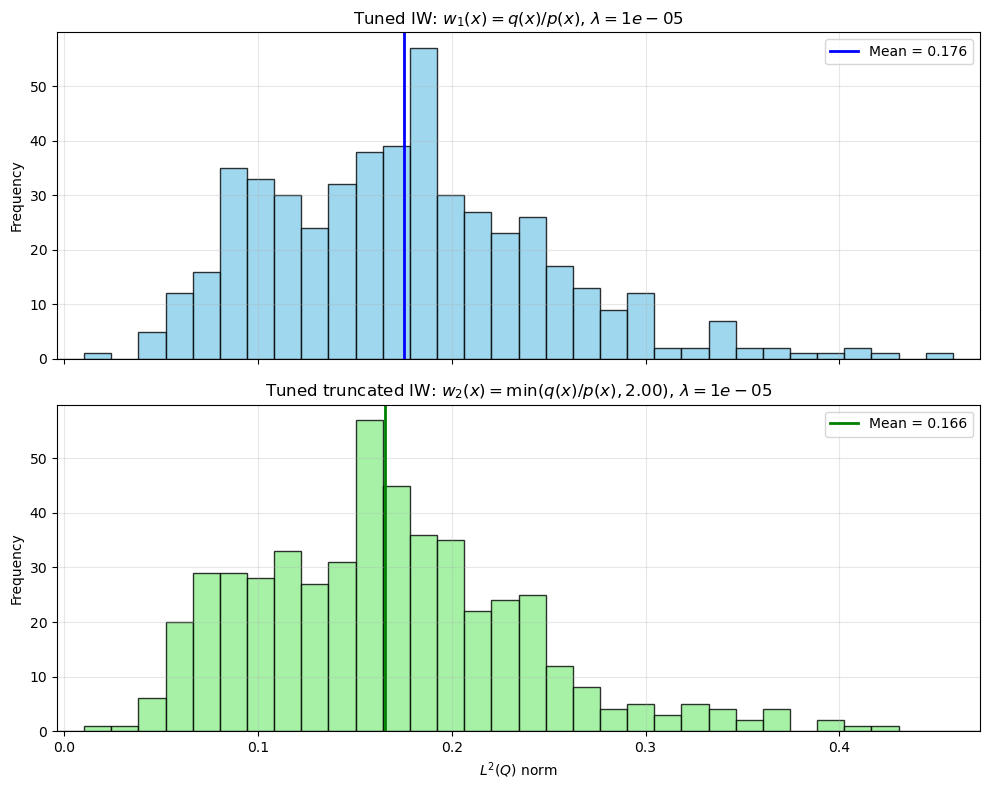

In [29]:
########## Plot comparison for tuned IW and tuned truncated IW

print(f"===== Summary over {N_REP} repetitions =====")
print(
    f"w1(x)=q(x)/p(x), tuned lambda={best_lambda_w1:.4g}: "
    f"mean={errors_w1.mean():.4f}, std={errors_w1.std():.4f}, "
    f"min={errors_w1.min():.4f}, max={errors_w1.max():.4f}"
)
print(
    f"w2(x)=min(q/p,{best_weight_cap:.2f}), tuned lambda={best_lambda_w2:.4g}: "
    f"mean={errors_w2.mean():.4f}, std={errors_w2.std():.4f}, "
    f"min={errors_w2.min():.4f}, max={errors_w2.max():.4f}"
)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

x_min = min(errors_w1.min(), errors_w2.min())
x_max = max(errors_w1.max(), errors_w2.max())
pad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)
x_min -= pad
x_max += pad
bins = np.linspace(x_min, x_max, 35)

axes[0].hist(errors_w1, bins=bins, color="skyblue", edgecolor="black", alpha=0.8)
axes[0].axvline(errors_w1.mean(), color="blue", linestyle="-", linewidth=2, label=f"Mean = {errors_w1.mean():.3f}")
axes[0].set_title(rf"Tuned IW: $w_1(x)=q(x)/p(x)$, $\lambda={best_lambda_w1:.4g}$")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(errors_w2, bins=bins, color="lightgreen", edgecolor="black", alpha=0.8)
axes[1].axvline(errors_w2.mean(), color="green", linestyle="-", linewidth=2, label=f"Mean = {errors_w2.mean():.3f}")
axes[1].set_title(
    rf"Tuned truncated IW: $w_2(x)=\min(q(x)/p(x),{best_weight_cap:.2f})$, "
    rf"$\lambda={best_lambda_w2:.4g}$"
)
axes[1].set_xlabel(r"$L^2(Q)$ norm")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(x_min, x_max)
axes[1].legend()
axes[1].grid(alpha=0.3)

from pathlib import Path
output_dir = Path("l2norm_imgs")
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(output_dir / "03_importance_weighting_l2q_hist.png", dpi=300, bbox_inches="tight")
plt.show()
